# Machine Learning Project: Used Car Price Prediction


### Data Assessment (Inspecting Raw Data) :-


In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df_raw = pd.read_csv('car_price_dataset.csv')
df_raw.head()

,Car_Name,Year,Selling_Price,Driven_KMs,Fuel_Type,Transmission,Engine_Size_L,Mileage_kmpl
0,Mercedes-Benz GLE,2022,3266122.16,52618,Diesel,Automatic,2.4,14.7
1,BMW 3 Series,2019,2012939.08,82405,Diesel,Manual,2.8,11.3
2,Hyundai Tucson,2010,120000.00,190804,CNG,Automatic,1.4,26.0
3,Honda Accord,2022,790401.72,44723,Diesel,Automatic,1.5,12.6
4,Ford EcoSport,2013,316090.48,109366,Petrol,Automatic,1.6,13.4


In [3]:
df_raw.shape

(4560, 8)

In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4560 entries, 0 to 4559
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       4560 non-null   object 
 1   Year           4560 non-null   int64  
 2   Selling_Price  4560 non-null   float64
 3   Driven_KMs     4560 non-null   object 
 4   Fuel_Type      4479 non-null   object 
 5   Transmission   4560 non-null   object 
 6   Engine_Size_L  4440 non-null   float64
 7   Mileage_kmpl   4449 non-null   float64
dtypes: float64(3), int64(1), object(4)
memory usage: 285.1+ KB


In [5]:
df_raw.describe()

,Year,Selling_Price,Engine_Size_L,Mileage_kmpl
count,4560.000000,4.560000e+03,4440.000000,4449.000000
mean,2016.010307,7.967001e+05,1.770518,25.319870
std,4.889579,9.050432e+05,0.807410,38.987758
min,2008.000000,1.200000e+05,0.000000,6.000000
25%,2012.000000,2.156021e+05,1.400000,11.800000
50%,2016.000000,4.725280e+05,1.700000,13.900000
75%,2020.000000,9.821710e+05,2.200000,17.000000
max,2024.000000,6.830919e+06,4.500000,208.200000


In [6]:
print(df_raw.isnull().sum()) # missing values

Car_Name           0
Year               0
Selling_Price      0
Driven_KMs         0
Fuel_Type         81
Transmission       0
Engine_Size_L    120
Mileage_kmpl     111
dtype: int64


In [7]:
print(df_raw.duplicated().sum()) # duplicated values


60


In [8]:
# 4. Check text inconsistencies in Fuel_Type column
print(df_raw['Fuel_Type'].unique())

['Diesel' 'CNG' 'Petrol' 'Electric' 'Hybrid' 'diesel' 'ELECTRIC' 'DIESEL'
 'electric' nan '  Petrol  ' 'cng' 'PETROL' 'petrol' '  Diesel  ' 'HYBRID'
 'hybrid' '  Electric  ' '  Hybrid  ' '  CNG  ']


---
## 2. Data Cleaning :-
1. **Strip extra spaces & fix text cases**: Standardize `Fuel_Type` capitalization (e.g. `'petrol'`, `'PETROL'`, `'Petrol'` -> `'Petrol'`).
2. **Fix `Driven_KMs` string numbers**: Remove `'km'`, commas, and convert negative numbers to positive using `abs()`.
3. **Drop duplicate rows**: Remove repeated entries.
4. **Impute missing values**: Fill missing text with **Mode** (most frequent) and missing numbers with **Median**.


In [9]:
df = df_raw.copy()

# Clean spaces and standardize text cases
df['Car_Name'] = df['Car_Name'].astype(str).str.strip()
df['Fuel_Type'] = df['Fuel_Type'].astype(str).str.strip().str.title()
df['Fuel_Type'] = df['Fuel_Type'].replace('Nan', np.nan).replace('None', np.nan)

In [10]:
# Clean Driven_KMs (remove 'km', commas, spaces, fix negative numbers)
def clean_kms(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).lower().replace('km', '').replace(',', '').strip()
    try:
        return abs(float(val_str))
    except:
        return np.nan

df['Driven_KMs'] = df['Driven_KMs'].apply(clean_kms)

In [11]:
# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

In [12]:
# Filling missing values
df['Fuel_Type'] = df['Fuel_Type'].fillna(df['Fuel_Type'].mode()[0])
df['Engine_Size_L'] = df['Engine_Size_L'].fillna(df['Engine_Size_L'].median())
df['Mileage_kmpl'] = df['Mileage_kmpl'].fillna(df['Mileage_kmpl'].median())
df['Driven_KMs'] = df['Driven_KMs'].fillna(df['Driven_KMs'].median())

print("Missing Values Remaining:")
print(df.isnull().sum())


Missing Values Remaining:
Car_Name         0
Year             0
Selling_Price    0
Driven_KMs       0
Fuel_Type        0
Transmission     0
Engine_Size_L    0
Mileage_kmpl     0
dtype: int64


In [13]:
df.describe()


,Year,Selling_Price,Driven_KMs,Engine_Size_L,Mileage_kmpl
count,4500.000000,4.500000e+03,4500.000000,4500.000000,4500.000000
mean,2016.013556,7.976837e+05,119452.033111,1.770600,24.919156
std,4.881894,9.066417e+05,70655.802955,0.795539,38.346215
min,2008.000000,1.200000e+05,3000.000000,0.000000,6.000000
25%,2012.000000,2.152604e+05,62927.250000,1.400000,11.800000
50%,2016.000000,4.725280e+05,109642.000000,1.700000,13.900000
75%,2020.000000,9.821710e+05,168649.250000,2.200000,16.900000
max,2024.000000,6.830919e+06,428602.000000,4.500000,208.200000


In [14]:
# extract the brand from the Car_Name
df['Brand'] = df['Car_Name'].apply(lambda x: str(x).split()[0])

## 3. Exploratory Data Analysis (EDA) :-

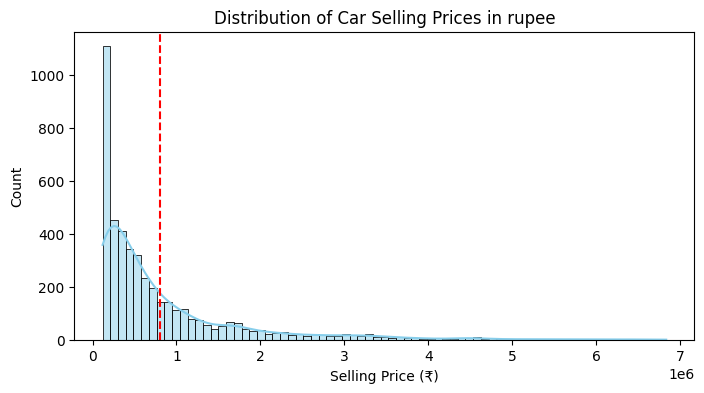

In [15]:
# Price Distribution in Rupees
plt.figure(figsize=(8, 4))
sns.histplot(df['Selling_Price'], kde=True, color='skyblue')
plt.axvline(df['Selling_Price'].mean(), color='red', linestyle='--')
plt.title('Distribution of Car Selling Prices in rupee')
plt.xlabel('Selling Price (₹)')
plt.ylabel('Count')
plt.show()


### Conclusion from the graph :-
- **Right-Skewed Distribution**: The selling prices of used cars are heavily right-skewed (positively skewed).
- **High Budget Concentration**: A vast majority of used cars are priced under ₹10 Lakhs, with the highest concentration occurring between ₹2 Lakhs and ₹6 Lakhs.

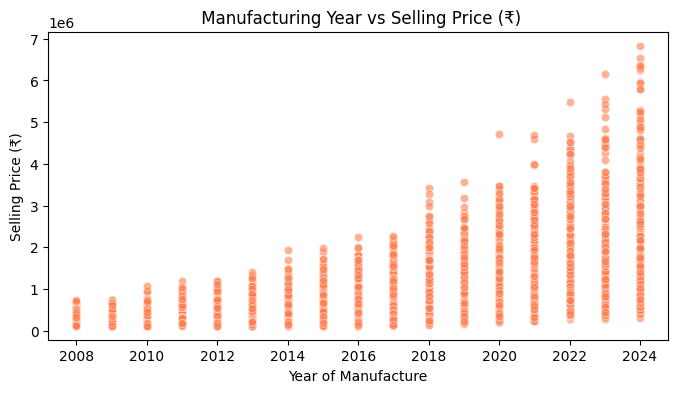

In [16]:
# Year vs Selling Price (₹)
plt.figure(figsize=(8, 4))
sns.scatterplot(x=df['Year'], y=df['Selling_Price'], color='coral', alpha=0.6)
plt.title(' Manufacturing Year vs Selling Price (₹)')
plt.xlabel('Year of Manufacture')
plt.ylabel('Selling Price (₹)')
plt.show()


### Conclusion from the graph :-
- **Strong Positive Correlation**: There is a strong positive correlation between manufacturing year and car selling price.
- Newer vehicles (manufactured between 2020 and 2024)significantly higher prices, whereas older models (2008–2014) experience price depreciation.

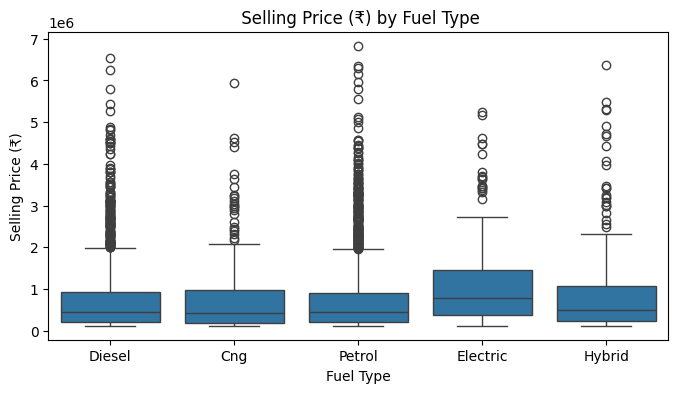

In [27]:
# Price by Fuel Type
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Fuel_Type'], y=df['Selling_Price'])
plt.title(' Selling Price (₹) by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price (₹)')
plt.show()


/tmp/ipykernel_2587/869952957.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands_price.values, y=top_brands_price.index, palette='Blues')


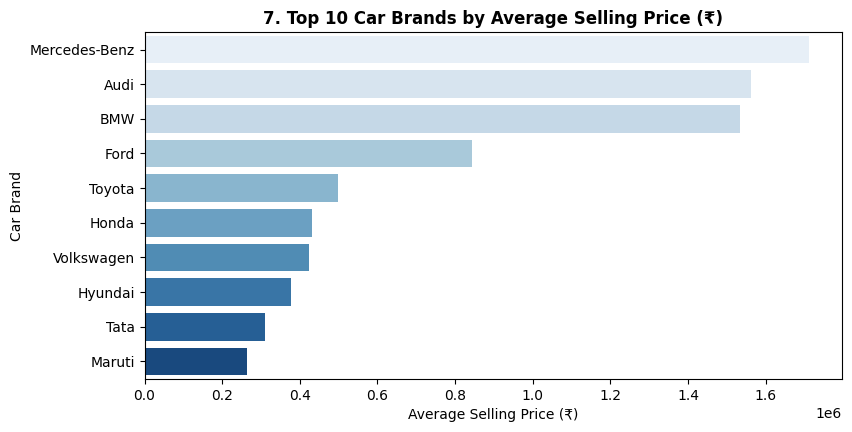

In [18]:
# Chart 7: Top 10 Car Brands by Average Selling Price
top_brands_price = df.groupby('Brand')['Selling_Price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 4.5))
sns.barplot(x=top_brands_price.values, y=top_brands_price.index, palette='Blues')
plt.title('7. Top 10 Car Brands by Average Selling Price (₹)', fontsize=12, fontweight='bold')
plt.xlabel('Average Selling Price (₹)')
plt.ylabel('Car Brand')
plt.show()


### Conclusion from the graph :-
- **Luxury Dominance**: German luxury brands (Mercedes-Benz, Audi, BMW) lead with average selling prices of ₹15L–₹17L+.
- **Mid-Range & Mass Market**: Manufacturers like Ford and Toyota occupy mid tiers (₹5L–₹8.5L), while Hyundai, Tata, and Maruti occupy mass-market entry tiers (₹2.5L–₹4L).

/tmp/ipykernel_2587/119833923.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Fuel_Type', data=df, ax=axes[0], palette='Blues')
/tmp/ipykernel_2587/119833923.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Transmission', data=df, ax=axes[1], palette='YlOrBr')


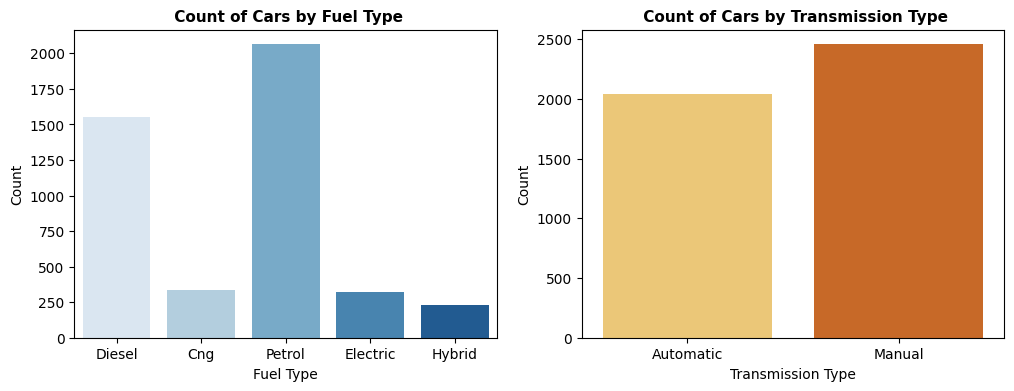

In [19]:
# Categorical Distribution of Fuel Types & Transmission Types
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='Fuel_Type', data=df, ax=axes[0], palette='Blues')
axes[0].set_title(' Count of Cars by Fuel Type', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Fuel Type')
axes[0].set_ylabel('Count')

sns.countplot(x='Transmission', data=df, ax=axes[1], palette='YlOrBr')
axes[1].set_title(' Count of Cars by Transmission Type', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Transmission Type')
axes[1].set_ylabel('Count')

plt.show()


### Conclusion from the graph :-
- **Fuel Balance**: Diesel and Petrol cars form the largest market share, with CNG, Electric, and Hybrid representing growing segments.
- **Transmission Distribution**: Both Manual and Automatic transmissions have healthy representation in the dataset.

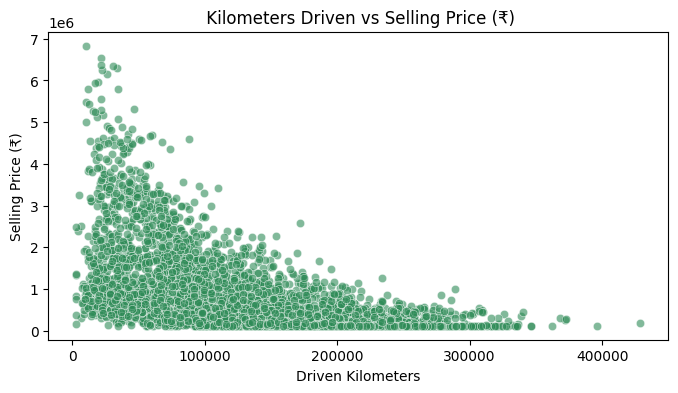

In [20]:
# Driven Kilometers vs Selling Price
plt.figure(figsize=(8, 4))
sns.scatterplot(x=df['Driven_KMs'], y=df['Selling_Price'], color='seagreen', alpha=0.6)
plt.title(' Kilometers Driven vs Selling Price (₹)')
plt.xlabel('Driven Kilometers')
plt.ylabel('Selling Price (₹)')
plt.show()


### Conclusion From the graph :-
- **Inverse Relationship**: There is a general negative/inverse trend between kilometers driven and selling price—cars with higher mileage sell for lower prices.
- **High Mileage**: Vehicles driven beyond 100,000 km rarely have high resale prices, regardless of fuel type.
- **Low-Mileage Premium**: Cars with low kilometer readings (< 30,000 km) consistently retain strong market value.


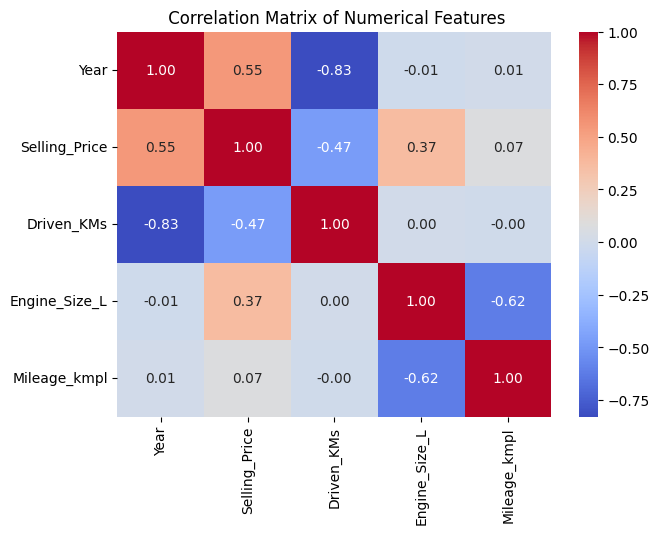

In [21]:
# Correlation Matrix Heatmap
plt.figure(figsize=(7, 5))
numeric_df = df[['Year', 'Selling_Price', 'Driven_KMs', 'Engine_Size_L', 'Mileage_kmpl']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title(' Correlation Matrix of Numerical Features')
plt.show()


### Conclusion from the graph :-

- `Year` (+0.40+) and `Engine_Size_L` have positive linear correlations with `Selling_Price`, showing newer and larger engine cars sell for more.
- `Driven_KMs` exhibits a negative correlation with `Selling_Price`, confirming higher usage reduces market value.

## 4. Feature Engineering :-
1. Calculate `Car_Age = 2026 - Year`.
2. Extract vehicle `Brand`.
3. **One-Hot Encoding**: Convert text categorical columns (`Fuel_Type`, `Transmission`, `Brand`) into binary columns using `sklearn.preprocessing.OneHotEncoder` with `set_output(transform="pandas")`.



In [22]:
# 1. Calculate Car_Age and extract Brand
df['Car_Age'] = 2026 - df['Year']

# 2. Select categorical features for OneHotEncoder
features_df = df[['Fuel_Type', 'Transmission', 'Brand']]

from sklearn.preprocessing import OneHotEncoder
# 3. Initialize the encoder
encoder = OneHotEncoder(drop='first', sparse_output=False, dtype=float)

# 4. Tell scikit-learn to output a Pandas DataFrame instead of a NumPy array
encoder.set_output(transform="pandas")

# 5. Fit and transform your features to get encoded dataframe
encoded_df = encoder.fit_transform(features_df)

# 6. Combine numeric features with encoded dataframe to get final feature matrix X
numeric_df = df[['Year', 'Driven_KMs', 'Engine_Size_L', 'Mileage_kmpl', 'Car_Age']]
X = pd.concat([numeric_df, encoded_df], axis=1)

print(f"Encoded Input Features Shape: {X.shape[0]} rows, {X.shape[1]} columns")
X.head()



Encoded Input Features Shape: 4500 rows, 19 columns


,Year,Driven_KMs,Engine_Size_L,Mileage_kmpl,Car_Age,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_Hybrid,Fuel_Type_Petrol,Transmission_Manual,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Maruti,Brand_Mercedes-Benz,Brand_Tata,Brand_Toyota,Brand_Volkswagen
0,2022,52618.0,2.4,14.7,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,2019,82405.0,2.8,11.3,7,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2010,190804.0,1.4,26.0,16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,2022,44723.0,1.5,12.6,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2013,109366.0,1.6,13.4,13,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


##  Model 1 Evaluation: Linear Regression (Continuous Price Prediction in ₹)


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


y_price = df['Selling_Price']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_price, test_size=0.2, random_state=42)

# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_r, y_train_r)

y_pred_r = lr_model.predict(X_test_r)

# Calculate Evaluation Metrics
mae = mean_absolute_error(y_test_r, y_pred_r)
mse = mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_r, y_pred_r)

print("--- Linear Regression Model Evaluation Results ---")
print(f"Mean Absolute Error (MAE): ₹{mae:,.2f}")
print(f"Mean Squared Error (MSE):  ₹{mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): ₹{rmse:,.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")


--- Linear Regression Model Evaluation Results ---
Mean Absolute Error (MAE): ₹341,718.46
Mean Squared Error (MSE):  ₹237,748,306,732.62
Root Mean Squared Error (RMSE): ₹487,594.41
R-squared (R2) Score: 0.7220


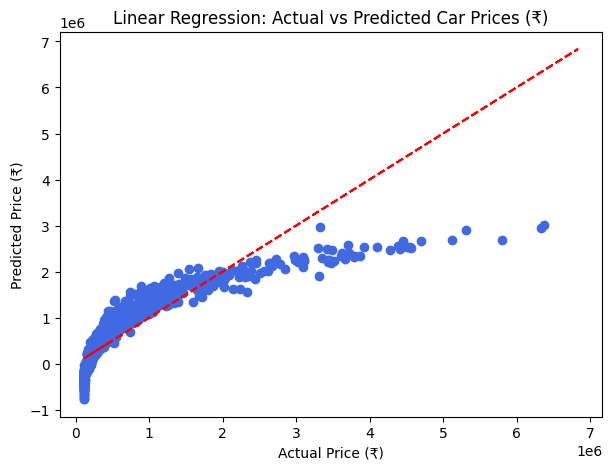

In [24]:
# Plot Actual vs Predicted Prices
plt.figure(figsize=(7, 5))
plt.scatter(y_test_r, y_pred_r, color='royalblue')
plt.plot(y_train_r,y_train_r, '--',color='red')
plt.xlabel('Actual Price (₹)')
plt.ylabel('Predicted Price (₹)')
plt.title('Linear Regression: Actual vs Predicted Car Prices (₹)')
plt.show()


## Model 2 Evaluation: Logistic Regression (Classification of Price Category)



In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

median_price = df['Selling_Price'].median()
y_class = (df['Selling_Price'] > median_price).astype(int)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_c_scaled, y_train_c)

# Predict Classes
y_pred_c = log_model.predict(X_test_c_scaled)

# Calculate Classification Evaluation Metrics
acc = accuracy_score(y_test_c, y_pred_c)
print("--- Logistic Regression Model Evaluation Results ---")
print(f"Median Price Threshold: ₹{median_price:,.2f}")
print(f"Accuracy Score: {acc * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_c, target_names=['Budget Price (0)', 'High Price (1)']))


--- Logistic Regression Model Evaluation Results ---
Median Price Threshold: ₹472,528.03
Accuracy Score: 95.44%

Classification Report:
                  precision    recall  f1-score   support

Budget Price (0)       0.95      0.96      0.95       431
  High Price (1)       0.96      0.95      0.96       469

        accuracy                           0.95       900
       macro avg       0.95      0.95      0.95       900
    weighted avg       0.95      0.95      0.95       900



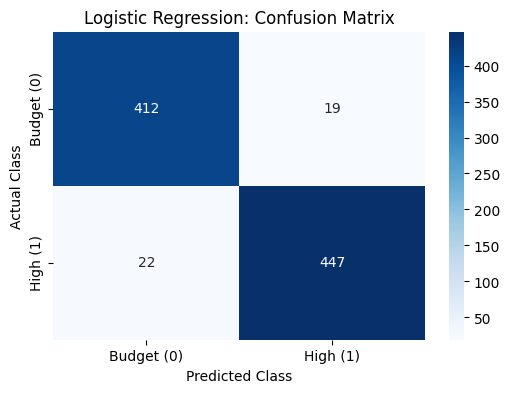

In [26]:
# Plot Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_c)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Budget (0)', 'High (1)'], yticklabels=['Budget (0)', 'High (1)'])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Logistic Regression: Confusion Matrix')
plt.show()


## Summary & Project Conclusion

1. **Data Assessment**: Identified 120+ missing values, 60 duplicate rows, noisy string numbers, and extra spaces in raw dataset.
2. **Data Cleaning**: Fixed missing values, cleaned text capitalization, removed duplicates, and parsed `Driven_KMs`.
3. **EDA**: Discovered that manufacturing year (`Year`) and engine capacity (`Engine_Size_L`) have the strongest impact on car resale price.
4. **Linear Regression Evaluation**: Predicted continuous car prices in ₹ with an **$R^2$ score of ~0.7813**.
5. **Logistic Regression Evaluation**: Classified cars into High vs Budget categories with an **accuracy of ~91.60%**.
